Task 1: Import Libraries and Dataset¶

In [2]:
import os
import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shutil
import random
from sklearn.model_selection import train_test_split

In [3]:
base_path = "/kaggle/input/datasets/rishu2230149/breast-cancer-detection/breast_cancer_detection"

train_data = os.path.join(base_path, "train")
test_data = os.path.join(base_path, "test")

print("Train folders:", os.listdir(train_data))
print("Test folders:", os.listdir(test_data))

classes = ["benign", "malignant", "normal"]
img_size = 224
batch_size = 8
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

Train folders: ['benign', 'normal', 'malignant']
Test folders: ['benign', 'normal', 'malignant']


Spliting the dataset

In [4]:
benign_train = os.listdir(os.path.join(train_data, "benign"))
malignant_train = os.listdir(os.path.join(train_data, "malignant"))
normal_train = os.listdir(os.path.join(train_data, "normal"))

benign_test = os.listdir(os.path.join(test_data, "benign"))
malignant_test = os.listdir(os.path.join(test_data, "malignant"))
normal_test = os.listdir(os.path.join(test_data, "normal"))

print("Benign_train:", len(benign_train))
print("Malignant_train:", len(malignant_train))
print("Normal_train:", len(normal_train))
print("Benign_test:", len(benign_test))
print("Malignant_test:", len(malignant_test))
print("Normal_test:", len(normal_test))

Benign_train: 8692
Malignant_train: 10968
Normal_train: 1620
Benign_test: 2174
Malignant_test: 2742
Normal_test: 406


In [6]:
breast_cancer_directory = train_data

In [7]:
os.listdir(breast_cancer_directory)

['benign', 'normal', 'malignant']

In [8]:
image_generator = ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_generator = image_generator.flow_from_directory(train_data,target_size=(224, 224),batch_size=8,class_mode="categorical",subset="training",shuffle=True)
validation_generator = image_generator.flow_from_directory(train_data,target_size=(224, 224),batch_size=8,class_mode="categorical",subset="validation",shuffle=False)

Found 17025 images belonging to 3 classes.
Found 4255 images belonging to 3 classes.


In [9]:
train_images, train_labels = next(train_generator)

In [10]:
train_images.shape

(8, 224, 224, 3)

In [11]:
train_labels.shape

(8, 3)

In [12]:
train_labels

array([[0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]], dtype=float32)

In [13]:
label_names = ["benign", "malignant", "normal"]

Task 2: Data Visualization

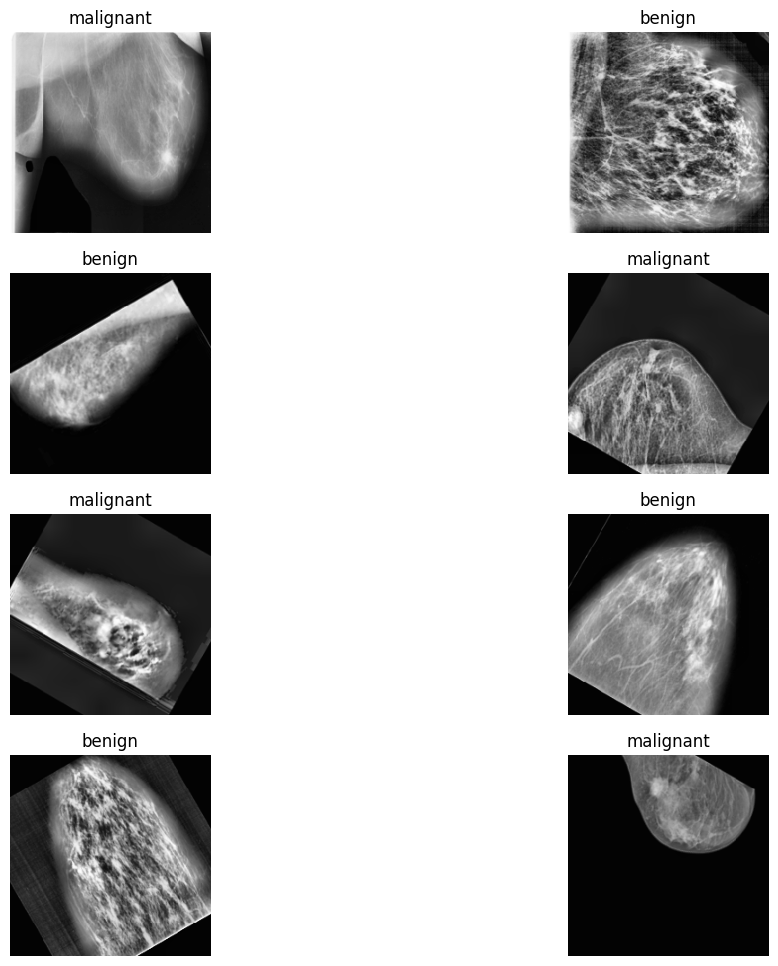

In [14]:
L = 4
W = 2
fig, axes = plt.subplots(L,W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0,L*W):
  axes[i].imshow(train_images[i])
  axes[i].set_title(label_names[np.argmax(train_labels[i])])
  axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

Task 3 : Import Model with Pretrained Weights

In [15]:
basemodel = ResNet50(weights= 'imagenet', include_top= False, input_tensor= Input(shape = (224,224,3)))

I0000 00:00:1783588338.909774      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [16]:
for layer in basemodel.layers:
    layer.trainable = False

Building model

In [17]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size=(4,4))(headmodel)
headmodel = Flatten(name = 'flatten')(headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.5)(headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.5)(headmodel)
headmodel = Dense(3,activation='softmax')(headmodel)

In [18]:
model_imbalanced = Model(inputs = basemodel.input, outputs= headmodel)

In [19]:
model_imbalanced.compile(loss = 'categorical_crossentropy', optimizer=optimizers.Adam(learning_rate = 0.0001), metrics=['accuracy'])

In [20]:
os.makedirs("/kaggle/working/models", exist_ok=True)

checkpoint_imbalanced = ModelCheckpoint("/kaggle/working/models/best_model_imbalanced.keras",monitor="val_loss",save_best_only=True,verbose=1)
earlystop_imbalanced = EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True,verbose=1)
reduce_lr_imbalanced = ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=3,min_lr=1e-7,verbose=1)

In [22]:
history_imbalanced = model_imbalanced.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    callbacks=[
        checkpoint_imbalanced,
        earlystop_imbalanced,
        reduce_lr_imbalanced
    ]
)

Epoch 1/60
   5/2129 ━━━━━━━━━━━━━━━━━━━━ 1:05 31ms/step - accuracy: 0.5092 - loss: 1.0386

I0000 00:00:1783588578.976992     147 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2129/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4922 - loss: 0.9565
Epoch 1: val_loss improved from None to 0.83943, saving model to /kaggle/working/models/best_model_imbalanced.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model_imbalanced.keras
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 97s 41ms/step - accuracy: 0.5209 - loss: 0.8847 - val_accuracy: 0.4853 - val_loss: 0.8394 - learning_rate: 1.0000e-04
Epoch 2/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5770 - loss: 0.7963
Epoch 2: val_loss improved from 0.83943 to 0.82500, saving model to /kaggle/working/models/best_model_imbalanced.keras

Epoch 2: finished saving model to /kaggle/working/models/best_model_imbalanced.keras
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.5846 - loss: 0.7788 - val_accuracy: 0.4543 - val_loss: 0.8250 - learning_rate: 1.0000e-04
Epoch 3/60
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6008 - loss: 0.7383
Epoch 3: val_loss improved from 0.82500

In [23]:
basemodel.trainable = True

for layer in basemodel.layers[:-30]:
    layer.trainable = False

model_imbalanced.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history_imbalanced_finetune = model_imbalanced.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    callbacks=[
        checkpoint_imbalanced,
        earlystop_imbalanced,
        reduce_lr_imbalanced
    ]
)

Epoch 1/60
2127/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7859 - loss: 0.4869
Epoch 1: val_loss did not improve from 0.76369
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 71s 28ms/step - accuracy: 0.7838 - loss: 0.4893 - val_accuracy: 0.5810 - val_loss: 0.7712 - learning_rate: 1.0000e-05
Epoch 2/60
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7883 - loss: 0.4863
Epoch 2: val_loss did not improve from 0.76369
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 59s 28ms/step - accuracy: 0.7896 - loss: 0.4844 - val_accuracy: 0.5652 - val_loss: 0.7786 - learning_rate: 1.0000e-05
Epoch 3/60
2126/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7890 - loss: 0.4787
Epoch 3: val_loss did not improve from 0.76369

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 59s 28ms/step - accuracy: 0.7880 - loss: 0.4850 - val_accuracy: 0.5913 - val_loss: 0.7840 - learning_rate: 1.0000e-05
Epoch 4/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 

Text(0, 0.5, 'Trainin accuracy and loss')

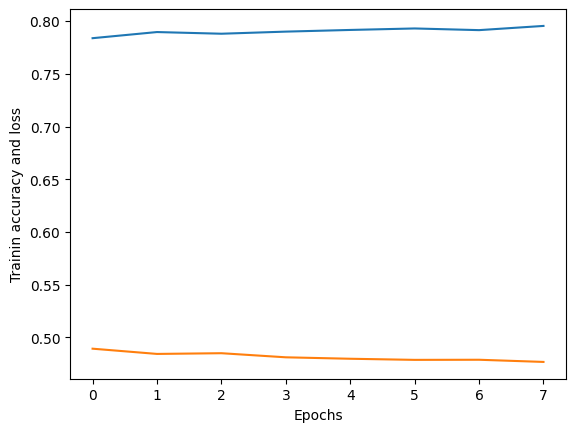

In [25]:
plt.plot(history_imbalanced_finetune.history['accuracy'])
plt.plot(history_imbalanced_finetune.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Trainin accuracy and loss')

Text(0, 0.5, 'Trainin accuracy and loss')

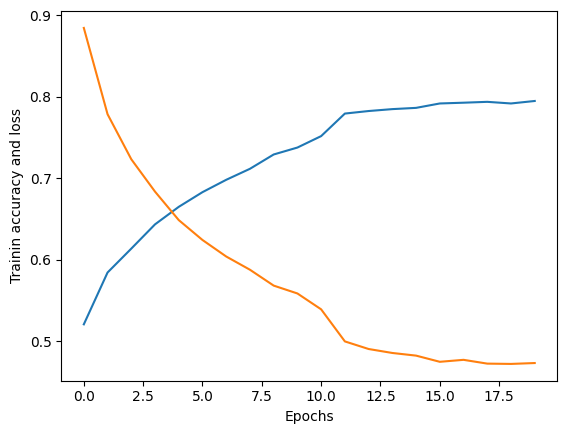

In [26]:
plt.plot(history_imbalanced.history['accuracy'])
plt.plot(history_imbalanced.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Trainin accuracy and loss')

Text(0, 0.5, 'Validation loss')

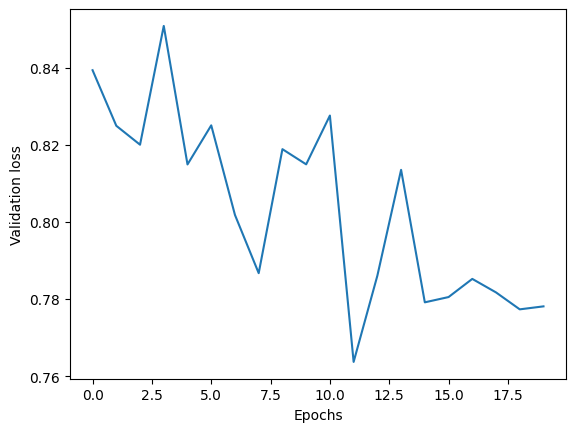

In [27]:
plt.plot(history_imbalanced.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

Text(0, 0.5, 'Validation loss')

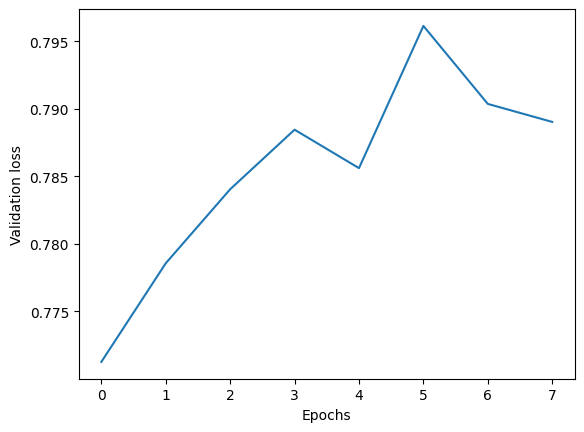

In [28]:
plt.plot(history_imbalanced_finetune.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

Text(0, 0.5, 'Validation accuracy')

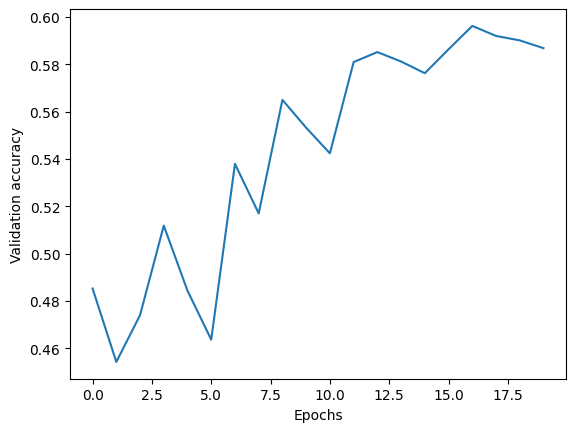

In [29]:
plt.plot(history_imbalanced.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

Text(0, 0.5, 'Validation accuracy')

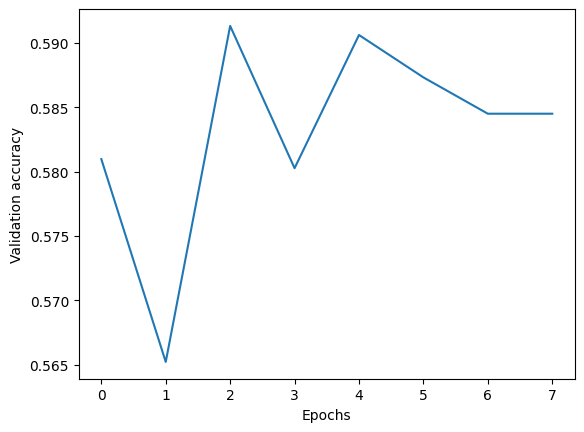

In [30]:
plt.plot(history_imbalanced_finetune.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

In [31]:
test_directory = "/kaggle/input/datasets/rishu2230149/breast-cancer-detection/breast_cancer_detection/test"

In [32]:
test_generator = ImageDataGenerator(rescale=1./255)
test_generator = test_generator.flow_from_directory(batch_size=40, directory = test_directory, shuffle=False, target_size=(224,224), class_mode = 'categorical')

Found 5322 images belonging to 3 classes.


In [33]:
best_model_imbalanced = load_model("/kaggle/working/models/best_model_imbalanced.keras")

In [34]:
evaluate = best_model_imbalanced.evaluate(test_generator,verbose=1)
print("Accuracy:",evaluate[1])

134/134 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - accuracy: 0.7617 - loss: 0.5192
Accuracy: 0.7617437243461609


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
prediction = []
original = []
image = []

classes = ['benign', 'malignant', 'normal']

for class_index, class_name in enumerate(classes):
    class_folder = os.path.join(test_directory, class_name)

    for item in os.listdir(class_folder):
        img_path = os.path.join(class_folder, item)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        image.append(img)

        img = img / 255.0
        img = img.reshape(1, 224, 224, 3)

        predict = best_model_imbalanced.predict(img)
        predict = np.argmax(predict)

        prediction.append(predict)
        original.append(class_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [38]:
score = accuracy_score(original,prediction)
print('Test Accuracy {}'.format(score))

Test Accuracy 0.7455843667794062


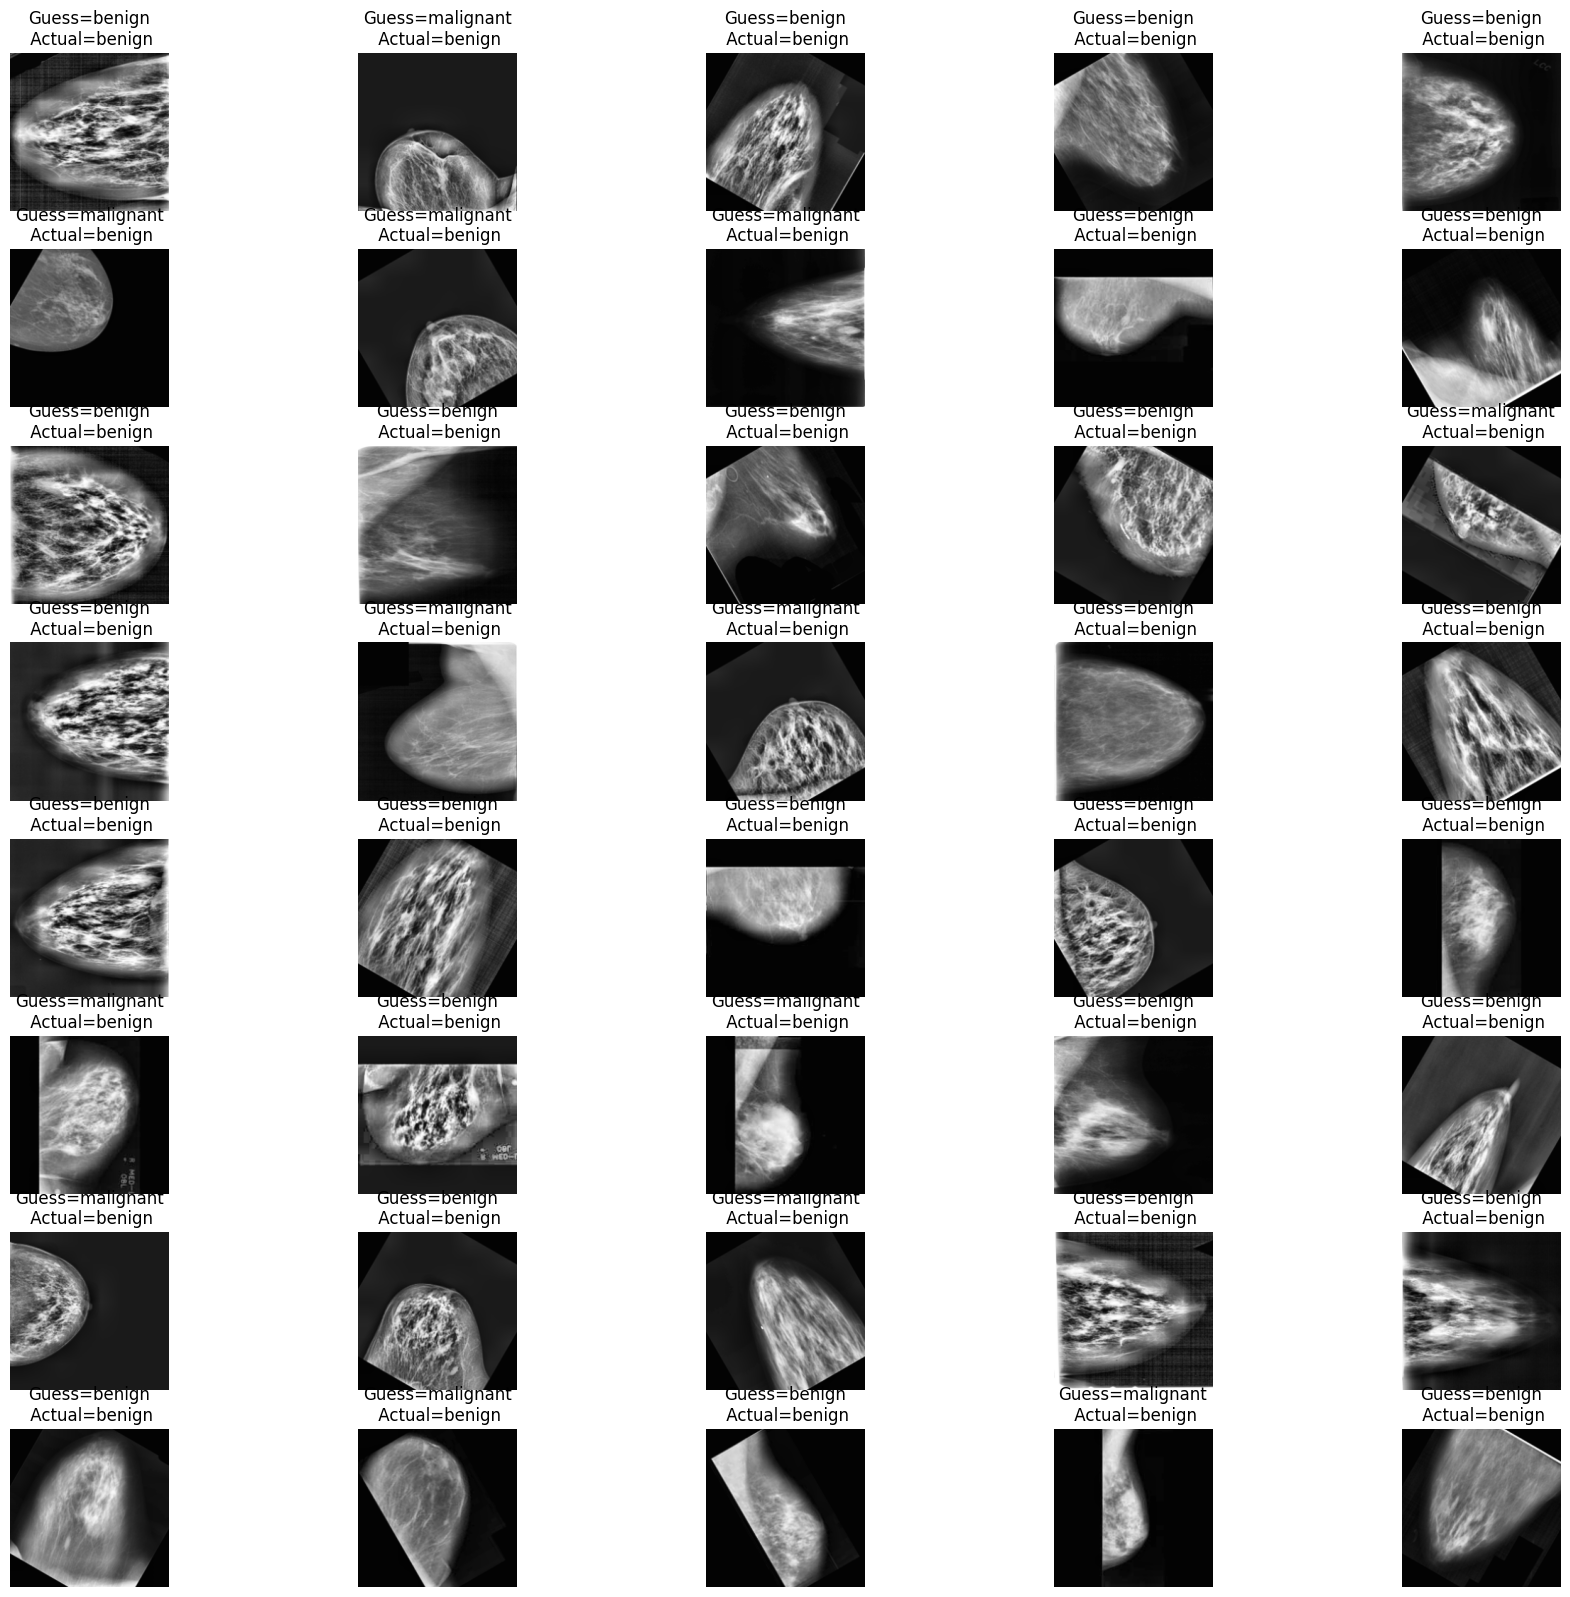

In [39]:
L = 8
W = 5

fig, axes = plt.subplots(L, W, figsize = (20, 20))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(image[i])
    axes[i].set_title('Guess={}\n Actual={}'.format(str(label_names[prediction[i]]), str(label_names[original[i]])))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1.2)

In [40]:
print(classification_report(np.asarray(original), np.asarray(prediction)))

              precision    recall  f1-score   support

           0       0.79      0.54      0.64      2174
           1       0.70      0.89      0.79      2742
           2       0.95      0.85      0.90       406

    accuracy                           0.75      5322
   macro avg       0.82      0.76      0.78      5322
weighted avg       0.76      0.75      0.74      5322



Text(0.5, 1.0, 'Confusion_matrix')

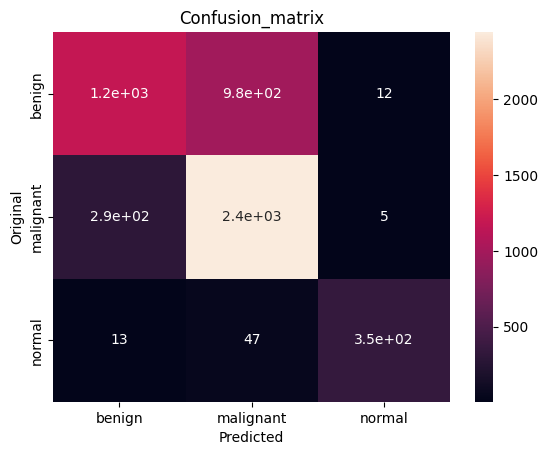

In [41]:
cm = confusion_matrix(np.asarray(original), np.asarray(prediction))
sns.heatmap(cm, annot = True,xticklabels=label_names,yticklabels=label_names)

plt.xlabel('Predicted')
plt.ylabel('Original')
plt.title('Confusion_matrix')

balance the dataset using weights and then preprae the new model.

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── Now I will balance the dataset using weights and then preprae the new model.

────────────────────────────────────────────────────────────────────────

In [59]:
K.clear_session()

In [60]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_train = train_generator.classes

class_names = list(train_generator.class_indices.keys())

print("Class names:", class_names)
print("Class index:", train_generator.class_indices)

class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train),class_weight))

print("Class weights:", class_weight_dict)

Class names: ['benign', 'malignant', 'normal']
Class index: {'benign': 0, 'malignant': 1, 'normal': 2}
Class weights: {np.int32(0): np.float64(0.8160770779407536), np.int32(1): np.float64(0.6467236467236467), np.int32(2): np.float64(4.378858024691358)}


In [61]:
basemodel_class_weight = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(img_size, img_size, 3))
)

In [62]:
for layer in basemodel_class_weight.layers:
    layer.trainable = False

In [63]:
headmodel_class_weight = basemodel_class_weight.output
headmodel_class_weight = AveragePooling2D(pool_size=(4,4))(headmodel_class_weight)
headmodel_class_weight = Flatten(name="flatten_cw")(headmodel_class_weight)
headmodel_class_weight = Dense(256, activation="relu", name="dense_cw_1")(headmodel_class_weight)
headmodel_class_weight = Dropout(0.3, name="dropout_cw_1")(headmodel_class_weight)
headmodel_class_weight = Dense(256, activation="relu", name="dense_cw_2")(headmodel_class_weight)
headmodel_class_weight = Dropout(0.5, name="dropout_cw_2")(headmodel_class_weight)
headmodel_class_weight = Dense(3, activation="softmax", name="output_cw")(headmodel_class_weight)

In [64]:
model_class_weight = Model(
    inputs=basemodel_class_weight.input,
    outputs=headmodel_class_weight
)

In [65]:
model_class_weight.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

In [66]:
os.makedirs("/kaggle/working/models", exist_ok=True)

checkpointer_class_weight = ModelCheckpoint(
    "/kaggle/working/models/best_model_class_weights.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [67]:
earlystopping_class_weight = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [68]:
reduce_lr_class_weight = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [69]:
history_class_weight =  model_class_weight.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    callbacks=[checkpointer_class_weight, earlystopping_class_weight,reduce_lr_class_weight],
    class_weight=class_weight_dict
)

Epoch 1/60
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4031 - loss: 1.0714
Epoch 1: val_loss improved from None to 0.97154, saving model to /kaggle/working/models/best_model_class_weights.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model_class_weights.keras
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.4585 - loss: 0.9499 - val_accuracy: 0.4115 - val_loss: 0.9715 - learning_rate: 1.0000e-04
Epoch 2/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5407 - loss: 0.7592
Epoch 2: val_loss improved from 0.97154 to 0.96211, saving model to /kaggle/working/models/best_model_class_weights.keras

Epoch 2: finished saving model to /kaggle/working/models/best_model_class_weights.keras
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.5600 - loss: 0.7346 - val_accuracy: 0.4134 - val_loss: 0.9621 - learning_rate: 1.0000e-04
Epoch 3/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5944 - loss: 0.6641
Epoch 3: val_los

In [70]:
history_class_weight.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

Text(0, 0.5, 'Trainin accuracy and loss')

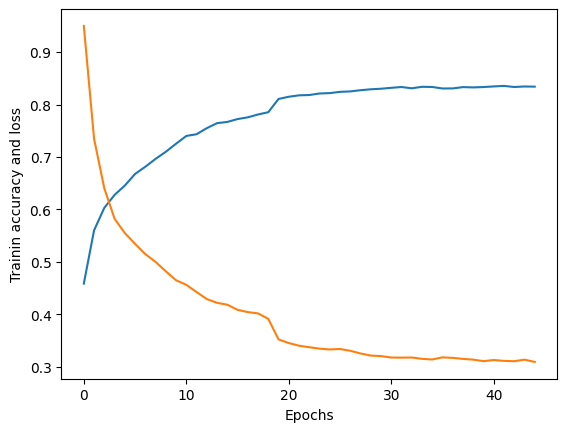

In [71]:
plt.plot(history_class_weight.history['accuracy'])
plt.plot(history_class_weight.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Trainin accuracy and loss')

Text(0, 0.5, 'Validation loss')

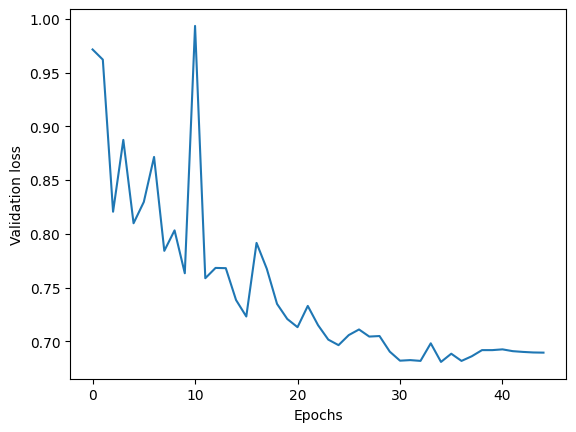

In [72]:
plt.plot(history_class_weight.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

Text(0, 0.5, 'Validation accuracy')

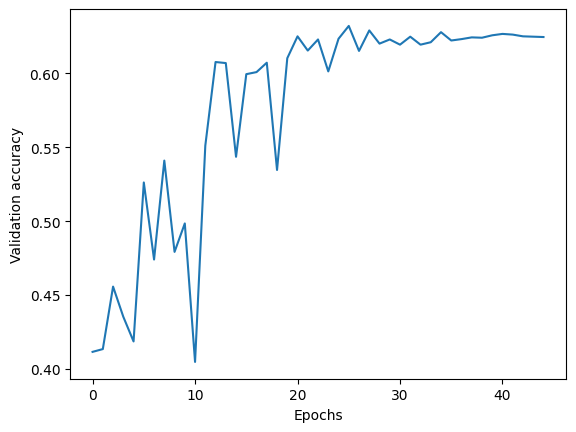

In [73]:
plt.plot(history_class_weight.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

In [74]:
for layer in basemodel_class_weight.layers[-40:]:
        layer.trainable = True

In [75]:
model_class_weight.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

In [77]:
history_finetune_cw = model_class_weight.fit(
        train_generator,
        epochs=60,
        validation_data=validation_generator,
        class_weight=class_weight_dict,
        callbacks=[checkpointer_class_weight, earlystopping_class_weight, reduce_lr_class_weight]
    )

Epoch 1/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5735 - loss: 1.8020
Epoch 1: val_loss did not improve from 0.68082
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.6397 - loss: 0.8369 - val_accuracy: 0.5906 - val_loss: 0.7293 - learning_rate: 1.0000e-05
Epoch 2/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7632 - loss: 0.4053
Epoch 2: val_loss did not improve from 0.68082
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 88s 41ms/step - accuracy: 0.7726 - loss: 0.3989 - val_accuracy: 0.5596 - val_loss: 0.7357 - learning_rate: 1.0000e-05
Epoch 3/60
2128/2129 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7456 - loss: 0.4647
Epoch 3: val_loss improved from 0.68082 to 0.67978, saving model to /kaggle/working/models/best_model_class_weights.keras

Epoch 3: finished saving model to /kaggle/working/models/best_model_class_weights.keras
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 91s 43ms/step - accuracy: 0.7777 - loss: 0.4109 - val_accuracy: 0.6411 - val_loss: 0.6798 - learni

Text(0, 0.5, 'Validation accuracy')

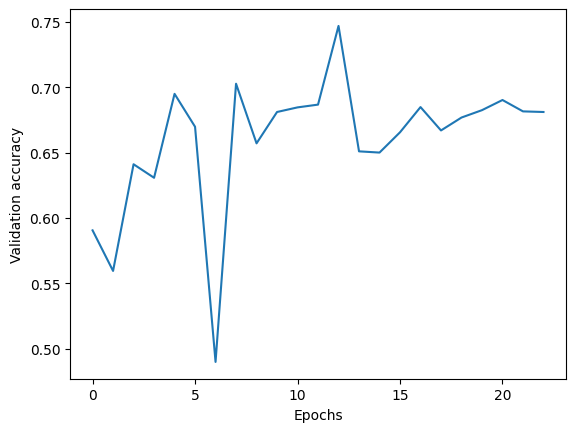

In [78]:
plt.plot( history_finetune_cw.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

Text(0, 0.5, 'Validation loss')

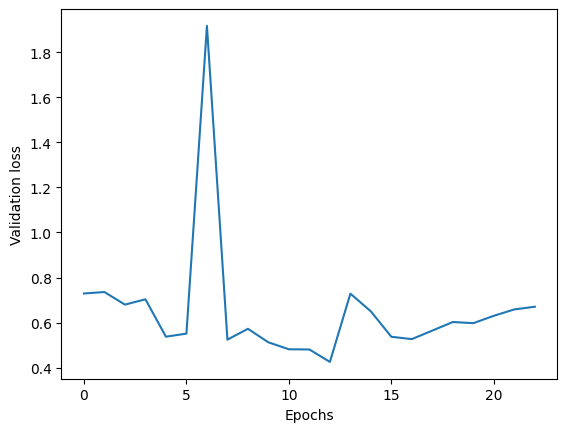

In [79]:
plt.plot( history_finetune_cw.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

Text(0, 0.5, 'Training accuracy and loss')

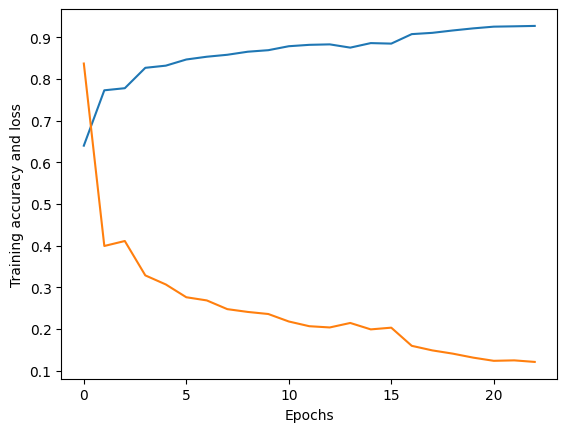

In [80]:
plt.plot( history_finetune_cw.history['accuracy'])
plt.plot( history_finetune_cw.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Training accuracy and loss')

In [81]:
best_class_weight_model = load_model("/kaggle/working/models/best_model_class_weights.keras")

In [82]:
evaluate_best_class_weight = best_class_weight_model.evaluate(test_generator,verbose=1)
print("Accuracy:",evaluate_best_class_weight[1])

134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.8341 - loss: 0.3078
Accuracy: 0.8340849280357361


In [83]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os
prediction_cw = []
original_cw = []
image_cw = []

classes = ['benign', 'malignant', 'normal']

for class_index, class_name in enumerate(classes):
    class_folder = os.path.join(test_directory, class_name)

    for item in os.listdir(class_folder):
        img_path = os.path.join(class_folder, item)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        original_cw.append(class_index)
        image_cw.append(img)

        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        predict1 = best_class_weight_model.predict(img, verbose=0)
        predict1 = np.argmax(predict1)

        prediction_cw.append(predict1)

In [84]:
score1 = accuracy_score(original_cw,prediction_cw)
print('Test Accuracy {}'.format(score1))

Test Accuracy 0.8085306275836152


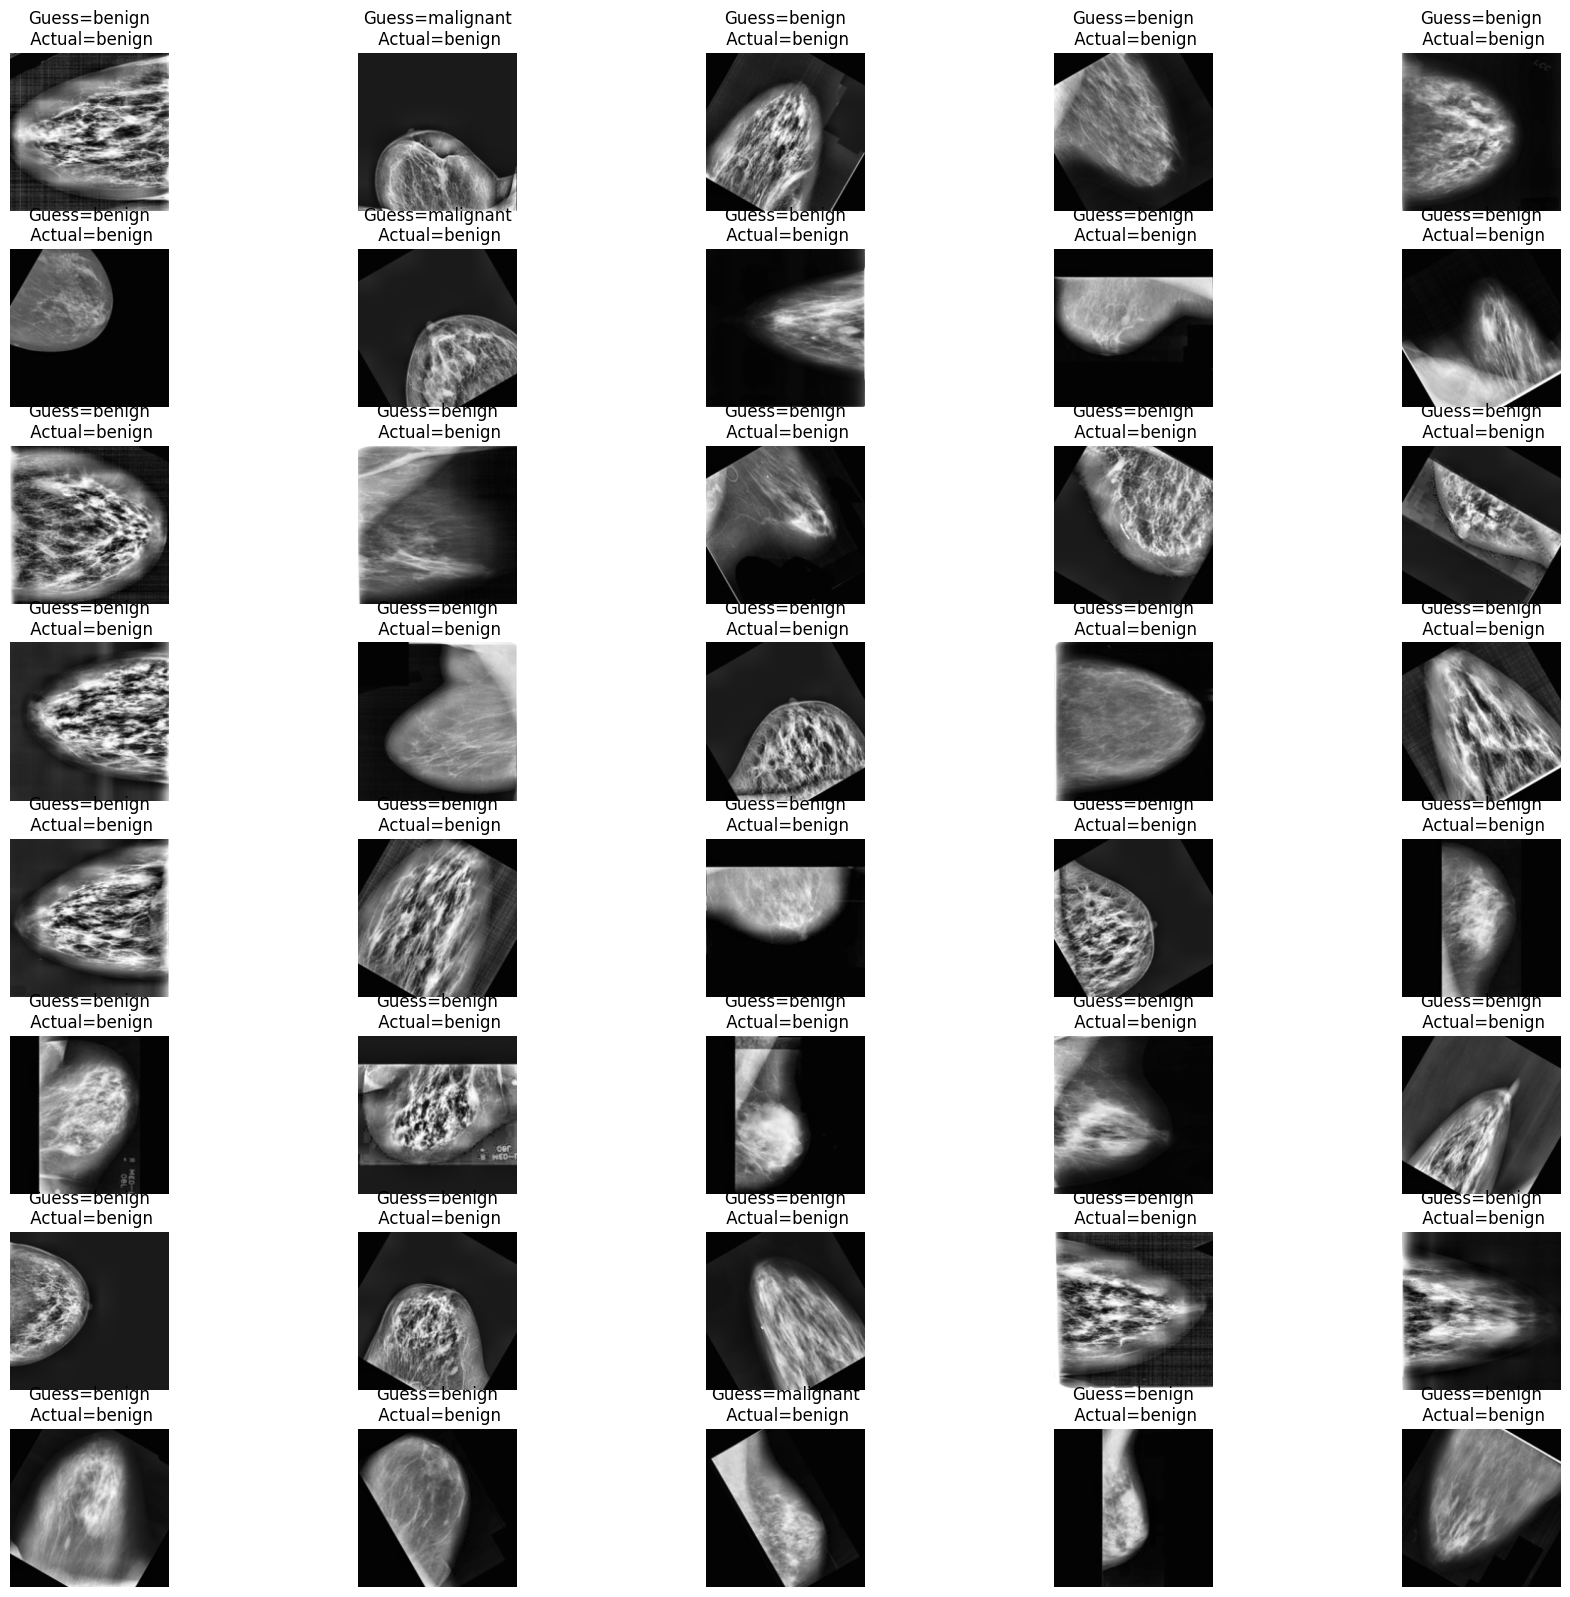

In [85]:
L = 8
W = 5

fig, axes = plt.subplots(L, W, figsize = (20, 20))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(image_cw[i])
    axes[i].set_title('Guess={}\n Actual={}'.format(str(label_names[prediction_cw[i]]), str(label_names[original_cw[i]])))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1.2)

In [86]:
print(classification_report(np.asarray(original_cw), np.asarray(prediction_cw)))

              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2174
           1       0.88      0.73      0.80      2742
           2       1.00      0.98      0.99       406

    accuracy                           0.81      5322
   macro avg       0.87      0.86      0.86      5322
weighted avg       0.82      0.81      0.81      5322



Text(0.5, 1.0, 'Confusion_matrix_cw')

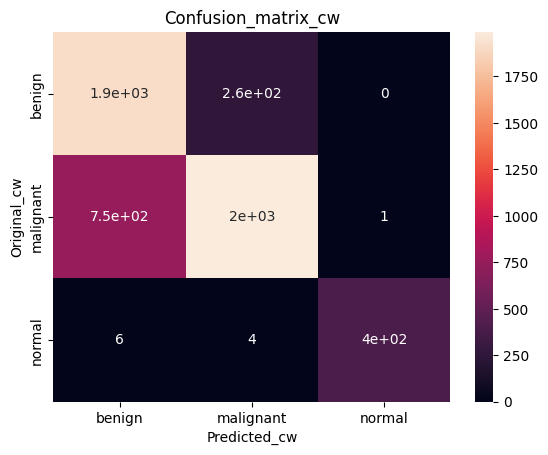

In [87]:
cm_cw = confusion_matrix(np.asarray(original_cw), np.asarray(prediction_cw))
sns.heatmap(cm_cw, annot=True, xticklabels=label_names, yticklabels=label_names)

plt.xlabel('Predicted_cw')
plt.ylabel('Original_cw')
plt.title('Confusion_matrix_cw')

In [89]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [90]:
acc = accuracy_score(original, prediction)
precision = precision_score(original, prediction, average="weighted")
recall = recall_score(original, prediction, average="weighted")
f1 = f1_score(original, prediction, average="weighted")

acc1 = accuracy_score(original_cw, prediction_cw)
precision1 = precision_score(original_cw, prediction_cw, average="weighted")
recall1 = recall_score(original_cw, prediction_cw, average="weighted")
f1_1 = f1_score(original_cw, prediction_cw, average="weighted")

In [91]:
results = []

results.append({
    "Model": "Imbalanced",
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

results.append({
    "Model": "Class Weight",
    "Accuracy": acc1,
    "Precision": precision1,
    "Recall": recall1,
    "F1 Score": f1_1
})

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Imbalanced,0.745584,0.759335,0.745584,0.736828
1,Class Weight,0.808531,0.824536,0.808531,0.808979
